In [ ]:
import keras
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input
from keras import layers

batch_size = 64 # number of images in each batch
img_size = (32, 32) # 32 x 32 pixel images in input data

train_dataset, validation_dataset = keras.utils.image_dataset_from_directory(
    '../../CIFAR-10-images/train',
    batch_size=batch_size, 
    image_size=img_size,
    label_mode='categorical',
    validation_split=0.2, 
    subset='both',
    seed=123)

test_dataset = keras.utils.image_dataset_from_directory(
    '../../CIFAR-10-images/test',
    batch_size=batch_size, 
    image_size=img_size,
    label_mode='categorical')



Apply VGG16 preprocessing to the images. 

Prefetch allows CPU and GPU to work in parallel. When GPU is working on batch 1 training, CPU is preparing batch 2 for training --> overall training process speeds up.

AUTOTUNE tells tensorflow my hardware specs and automatically optimizes the amount of batches being prepared in the background.

In [3]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

def apply_preprocessing(images, labels):
    return preprocess_input(images), labels

train_dataset = train_dataset.map(apply_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.map(apply_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(apply_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)

# Prefetch for performance
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [4]:
conv_base = keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(32, 32, 3),
    name="vgg16",
)

conv_base.trainable = False # Freeze the conv base

In [5]:
from tensorflow.keras import layers

inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)  # Augmentation runs ONLY during training automatically
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [7]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/30


2026-04-09 11:42:54.560037: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.3557 - loss: 4.8281 - val_accuracy: 0.5555 - val_loss: 1.3243
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.4911 - loss: 1.4624 - val_accuracy: 0.5897 - val_loss: 1.1998
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.5283 - loss: 1.3539 - val_accuracy: 0.6058 - val_loss: 1.1688
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.5422 - loss: 1.3023 - val_accuracy: 0.6107 - val_loss: 1.1488
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.5598 - loss: 1.2553 - val_accuracy: 0.6147 - val_loss: 1.1419
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.5688 - loss: 1.2425 - val_accuracy: 0.6159 - val_loss: 1.1532
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.5747 - loss: 1.2182 - val_accuracy: 0.6219 - val_loss: 1.1133
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.5810 - loss: 1.2108 - val_accurac

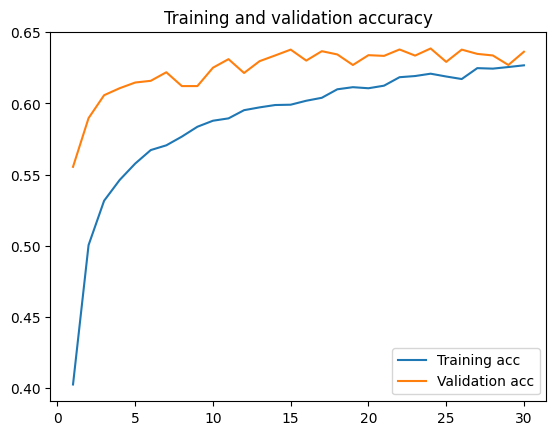

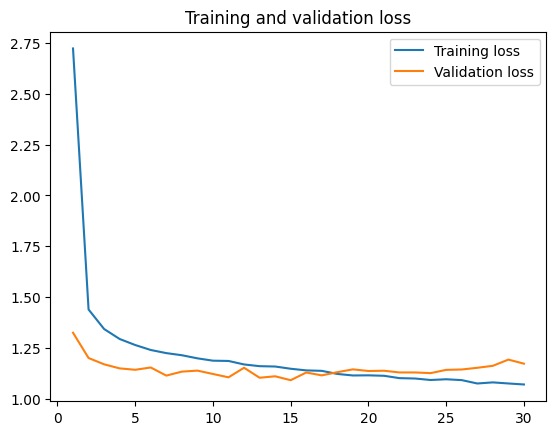

In [8]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()        

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

As seen from the plots, validation accuracy and validation loss are better in the beginning. This is because the training set images are going through augmentation and validation images are not. This prevents overfitting on the training data. Also during training 25% of the neurons are turned off with dropout. Dropout was also set to 40% and 15%, but the 25% gave the best results.

Around epoch 15 the model starts slightly overfitting. 
In the end we settle around 63% test accuracy, which is expected. The VGG16 features are trained on higher resolution images and not optimal for the CIFAR10 dataset, because the images are only 32x32.

It would be more beneficial to just train your own convolutional layers with CIFAR10 dataset and get better result than with the VGG16 convolutional base. Fine-tuning the model would also propably be beneficial. However, unfreezing the whole VGG16 convolutional net would not be optimal. The CIFAR10 dataset is not large enough to do so, it would only overwrite important generic features from VGG16 and the results would only be worse.

In [9]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f'Test accuracy: {test_acc:.4f}')


157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.6321 - loss: 1.1817
Test accuracy: 0.6318
